# Diffusion Models In Simulation-Based Inference: A Tutorial

This notebook introduces answers the following questions:

1. **What is simulation-based inference (SBI)?**
2. **What are diffusion models?**
3. **Why are diffusion models so special for SBI?**

_Author: Jonas Arruda_

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import logging

import numpy as np
import matplotlib.pyplot as plt
import keras

import ipywidgets as widgets
logging.getLogger("matplotlib").setLevel(logging.ERROR)
from misc.diffusion.kinematics_helper import InverseKinematicsModel

In [2]:
# Install if not already installed
%pip install scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


## Let's start with an example inference problem: [Inverse Kinematics](https://arxiv.org/pdf/2101.10763.pdf)


We consider a simple 3-segment planar robot arm with unknown configuration:
- one scalar **height offset** $h$,
- three **joint angles** $\alpha_1$, $\alpha_2$, $\alpha_3$.


The goal is: given an end position $\color{red}{\mathbf{x}}$ of a robot arm, infer the unknown arm configuration $\boldsymbol{\theta}=(h, \alpha_1, \alpha_2, \alpha_3)$.
Hence, we want to learn a mapping $\mathbf{x} \mapsto \boldsymbol\theta= (h, \alpha_1, \alpha_2, \alpha_3)$.

**Important:** this is a deliberately *non-identifiable* setting:
different angle combinations can yield very similar end positions.
That makes the inference task naturally **multimodal** and therefore a good stress test
for flexible inference methods such as diffusion models.

![Example simulations of the infeverse kinematics problem](misc/diffusion/example_simulations.png)

## How to solve this problem?

We will train a neural network to approximate the posterior distribution for the simple **inverse kinematics** problem.

Concretely, we will see how to:
- define a *prior* over parameters and a *simulator* producing synthetic observations,
- generate a training dataset by forward simulation,
- train an amortized inference model using **diffusion-based SBI** in [BayesFlow](https://bayesflow.org),
- draw approximate posterior samples for a new observation,
- compare diffusion models to *flow matching* and *consistency models*,
- make *post-hoc modifications* to inference via guided sampling.

## 1. Simulation-Based Inference (SBI)

In Bayesian inference, we want to infer the **posterior distribution**
$p(\boldsymbol\theta \mid \mathbf{x})$: a probability distribution over parameters
$\boldsymbol\theta$ given observed data $\mathbf{x}$.

A standard Bayesian workflow needs a prior $p(\boldsymbol\theta)$ and the likelihood $p(\mathbf{x}\mid \boldsymbol\theta)$ to be able to compute the posterior:

$p(\boldsymbol\theta\mid \mathbf{x}) \propto p(\mathbf{x}\mid\boldsymbol\theta)\,p(\boldsymbol\theta)$.


#### Key idea in **simulation-based inference (SBI)**:

Often we can **simulate** realistic data from the model without being able to evaluate the likelihood density and "fit" the model.


### SBI in one sentence

If we can sample from $p(\mathbf{x}\mid \boldsymbol\theta) p(\boldsymbol\theta)$, we can train a neural network
to approximate $p(\boldsymbol\theta \mid \mathbf{x})$ directly.


### Training a neural posterior estimator

1. We generate many simulated training pairs:
$(\boldsymbol\theta_i, \mathbf{x}_i) \sim p(\boldsymbol\theta)p(\mathbf{x}\mid\boldsymbol\theta)$
2. We train a neural network to learn the mapping
$\mathbf{x} \mapsto p(\boldsymbol\theta\mid \mathbf{x})$ (or something related to that mapping).

After training, inference for a new observation $\mathbf{x}_{\mathrm{obs}}$
becomes a fast forward-pass procedure:
$\boldsymbol\theta^{(1)},\dots,\boldsymbol\theta^{(N)} \sim q_\phi(\boldsymbol\theta\mid \mathbf{x}_{\mathrm{obs}})$,
where $q_\phi$ is the learned posterior approximation.

## SBI in [BayesFlow](https://bayesflow.org)

BayesFlow is a flexible Python library for efficient simulation-based inference (SBI) with neural networks, including diffusion models.

So let's train a neural posterior estimator! In BayesFlow, SBI workflows can be executed in just a few lines of code, as illustrated by the conceptual snippet below:


```python
import bayesflow as bf

# 1. Define prior and simulator
def my_prior():
    return {'parameters': θ}

def my_observation_model(parameters):
    return {'sim_data': x}

simulator = bf.make_simulator([my_prior, my_observation_model])

# 2. Create workflow
workflow = bf.BasicWorkflow(
    simulator=simulator,
    inference_network=bf.networks.DiffusionModel(...)
)

# 3. Train
workflow.fit_online(epochs=100)

# 4. Infer (amortized)
posterior_samples = workflow.sample(conditions=new_data)

# 5. Diagnose
...
```

## Solving [inverse kinematics](https://arxiv.org/pdf/2101.10763.pdf) with BayesFlow

In [3]:
import bayesflow as bf

INFO:2026-03-10 10:06:33,629:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


In [4]:
def prior():
    """
    Generates a random draw from a 4-dimensional Gaussian prior distribution with a
    spherical covariance matrix. The parameters represent a robot's arm
    configuration, with the first parameter indicating the arm's height and the 
    remaining three are angles.

    Returns
    -------
    params : A single draw from the 4-dimensional Gaussian prior.
    """
    scales = np.array([0.25, 0.5, 0.5, 0.5])
    prior_samples = np.random.normal(loc=0, scale=scales)
    return dict(parameters=prior_samples)

In [6]:
# Inverse Kinematics
def observation_model(parameters):
    """
    Returns the 2D coordinates of a robot arm given parameter vector.
    The first parameter represents the arm's height and the remaining three
    correspond to angles.

    Reference: https://arxiv.org/pdf/2101.10763.pdf

    Parameters
    ----------
    parameters   : The four model parameters which will determine the coordinates

    Returns
    -------
    x : The 2D coordinates of the arm
    """
    height_arm, angle_1, angle_2, angle_3 = parameters
    
    # length of segments
    l1: float = 0.5
    l2: float = 0.5
    l3: float = 1.0

    # Determine 2D position
    x1 = l1 * np.sin(angle_1)
    x1 += l2 * np.sin(angle_1 + angle_2)
    x1 += l3 * np.sin(angle_1 + angle_2 + angle_3) + height_arm

    x2 = l1 * np.cos(angle_1)
    x2 += l2 * np.cos(angle_1 + angle_2)
    x2 += l3 * np.cos(angle_1 + angle_2 + angle_3)
    return dict(observables=np.array([x1, x2]))

variable_names = ["height_arm", "angle_1", "angle_2", "angle_3"]
variable_names_nice = [" ".join(v.title().split('_')) for v in variable_names]

In [9]:
# we merge prior and observation model into a simulator
simulator = bf.make_simulator([prior, observation_model])

# now we create the simulator and generate training data
n_simulations = 10_000
training_data = simulator.sample(n_simulations)

print(f"Generated {n_simulations} simulations")
print(f"Observables shape (robot arm endpoints): {training_data['observables'].shape}")
print(f"Parameters shape (heights and angles): {training_data['parameters'].shape}")

Generated 10000 simulations
Observables shape (robot arm endpoints): (10000, 2)
Parameters shape (heights and angles): (10000, 4)


The dataset now contains:
- `parameters`: samples from the prior (our *ground truth* parameters),
- `observables`: corresponding simulated end positions.

This is the only supervision signal used for training: there are no data beyond simulations.

Next, we visualize the prior samples.

In [12]:
def plot_params_kinematic(params=None, params2=None):
    _, _ax = plt.subplots(1, 4, sharex=True, sharey=True, 
                           layout='constrained', figsize=(10, 2))
    for a_i, (a, name) in enumerate(zip(_ax, variable_names_nice)):
        if params2 is not None:
            a.hist(params2[:, a_i], density=True, color='black', alpha=.5)
        if params is not None:
            a.hist(params[:, a_i], density=True, color='#E7298A')
        a.set_xlabel(name)
    _ax[0].set_ylabel("Density")
    _ax[0].set_ylim(0, 1.6)
    _ax[0].set_xlim(-4, 4)


def plot_arm_posterior(posterior_samples, obs):
    _, _ax = plt.subplots(figsize=(3,3))

    _m = InverseKinematicsModel(
        linecolors=[['#E7298A'], ['#E7298A'], ['#E7298A']]
    )
    _m.update_plot_ax(_ax, 
        posterior_samples["parameters"][0], 
        obs['observables'][0, ::-1], 
        exemplar_color="#E7298A"
    )
    _ax.set_title('Arm Configurations')

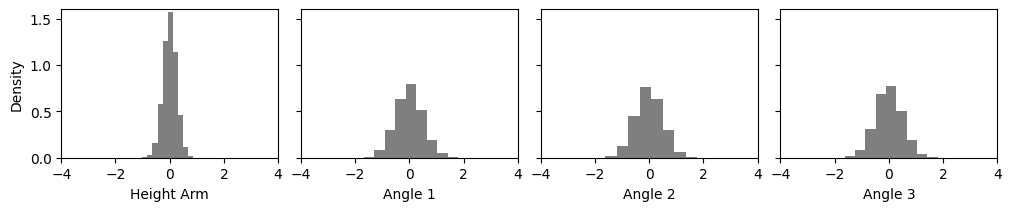

In [13]:
plot_params_kinematic(params2=training_data['parameters'])

Now let's train our neural estimator for 200 epochs! This will take around 2 minutes.

In [ ]:
# The adapter tells the workflow what the input to our neural network is and how the target is called
adapter = (
    bf.adapters.Adapter()
    .to_array() # we could do more complex transformations here
    .convert_dtype("float64", "float32")
    .rename("parameters", "inference_variables")
    .rename("observables", "inference_conditions")
)

# Create a simple workflow
workflow_dm = bf.BasicWorkflow(
    adapter=adapter,
    simulator=simulator,
    inference_network=bf.networks.DiffusionModel(),
    standardize='inference_conditions'
)

# Train for 200 epochs (passes through the simulated data)
history = workflow_dm.fit_offline(
    training_data,
    epochs=200,
    batch_size=128,
)

In [ ]:
# Test amortized inference on new data
obs = {"observables": np.array([[0, 1.5]])}


# Sampling with the trained diffusion model
posterior_samples_single = workflow_dm.sample(
    conditions=obs,
    num_samples=1000
)

# Plot posterior samples for the parameters
plot_params_kinematic(
    posterior_samples_single['parameters'][0],
    training_data['parameters']
)

# Simulate with the posterior samples and plot them
plot_arm_posterior(posterior_samples_single, obs)

So something seems to have been learned. We get a nice bimodal posterior!

But are we sure that this is the correct posterior?
Let's do amortized inference on 100 datasets!

In [ ]:
test_data = simulator.sample(100)

posterior_samples_test_data = workflow_dm.sample(
    conditions=test_data,
    num_samples=100,
)

fig = bf.diagnostics.plots.coverage(
    estimates=posterior_samples_test_data,
    targets=test_data,
    variable_names=variable_names_nice
)

### Amortized Bayesian Inference

SBI is typically used in an **amortized** way, meaning we train a neural inference model once
and then reuse it for many observations.

#### Why amortization matters

Traditional Bayesian methods (e.g., MCMC) solve one inference problem at a time:
- new observation $\mathbf{x}_{\mathrm{obs}}$  → rerun MCMC
- computational cost grows linearly with the number of datasets.

With amortized inference we instead learn a global conditional model:
$q_\phi(\boldsymbol\theta\mid\mathbf{x}) \approx p(\boldsymbol\theta\mid\mathbf{x})$.


After training, posterior sampling for a new observation is fast and convenient:
We can **solve many inference problems** with only one neural network!

#### A note on the “amortization gap”

The network must generalize to new $\mathbf{x}$ values across the full simulated data space.
If simulations do not cover the region of interest, the approximation may degrade.
In practice this is addressed by better priors, more simulations, or robust inference methods.

## 2. What are Diffusion Models?

Diffusion models are generative models that create samples by *iteratively denoising* random noise.

![Diffusion Models In Simulation-Based Inference: A Tutorial Review.](misc/diffusion/diffusion_model_review.jpeg)

### Forward process (Training)

We start with a clean sample $\boldsymbol\theta_0$ (here: a parameter vector) and gradually add noise:

$\boldsymbol\theta_t = \alpha_t\,\boldsymbol\theta_0 + \sigma_t\,\boldsymbol\epsilon, \quad \boldsymbol\epsilon \sim \mathcal{N}(0, I)$,

where $t \in [0,1]$ is a continuous diffusion time.
At $t \approx 1$, the distribution becomes close to pure noise.
Different choices of the *noise schedule* $\alpha_t$ and $\sigma_t$ determine how fast noise is added over time and have an impact on the performance later ([Arruda et al. (2025)](https://arxiv.org/abs/2512.20685)).

So what does the network actually learn?
It gets a noisy parameter $\boldsymbol\theta_t$ and the corresponding simulation $\mathbf{x}$ and predicts the score $\nabla_{\boldsymbol\theta_t}\!\log p(\boldsymbol\theta_t\mid\mathbf{x})$.

What is this score? It is the direction in which we need to move $\boldsymbol\theta_t$ to increase its probability under the posterior.
And it can be analytically computed from the noise schedule!

![Visualization of the score.](misc/diffusion/score_visual.jpg)

### Reverse process (Inference)

The diffusion model learns how to move from noisy samples back to clean samples.
In practice, sampling is performed by solving a learned reverse-time stochastic differential equation (SDE) or an equivalent deterministic ODE.

And how? The reverse SDE/ODE is purely defined in terms of the noise schedule and the learned score!

In [ ]:
t_slider_backward = widgets.FloatSlider(
    value=0.0,
    min=0,
    max=1.0,
    step=0.05,
    description='Diffusion t:',
    continuous_update=True,
)
t_slider_backward

In [ ]:
logging.getLogger("bayesflow").setLevel(logging.ERROR)

estimated_parameters_t = workflow_dm.sample(
    conditions=obs,
    num_samples=100,
    stop_time=t_slider_backward.value
)

plot_params_kinematic(
    estimated_parameters_t['parameters'][0]
)

print(f'Denoised Posterior at t={t_slider_backward.value}')

### Short Summary

- Diffusion model learns a score function: $\nabla_{\boldsymbol\theta} \log p(\boldsymbol\theta\mid\mathbf{x})$, the "direction" it which we need to solve the reverse SDE
- Sample by starting from noise and iteratively denoising

This provides a highly expressive posterior approximation, especially useful for:
- multimodal posteriors,
- high-dimensional parameters,
- post-hoc modifications during inference.

## More generative models

![Flow matching and consistency models as alternative parameterizations of diffusion models.](misc/diffusion/fm_cm_visual.jpg)

Related generative models can be considered a different *parameterization* of a **diffusion model**:
- **Flow matching**: we directly predict the vector field of the deterministic reverse path
- **Consistency models**: designed for very fast sampling by learning to jump directly to clean samples

All of these models are available in BayesFlow. So let's train some more models and compare their performance on our inverse kinematics problem!

In [ ]:
workflows = {}

workflows['diffusion_model'] = workflow_dm

workflow_fm = bf.BasicWorkflow(
    adapter=adapter,
    simulator=simulator,
    inference_network=bf.networks.FlowMatching(),
    standardize='inference_conditions'
)
workflows['flow_matching_model'] = workflow_fm

workflow_cm = bf.BasicWorkflow(
    adapter=adapter,
    simulator=simulator,
    inference_network=bf.networks.StableConsistencyModel(),
    standardize='inference_conditions'
)
workflows['consistency_model'] = workflow_cm

for _name in workflows.keys():

    # Diffusion workflow is already trained, so we skip it here
    if _name != 'diffusion_model':
        workflows[_name].fit_offline(
            training_data,
            epochs=200,
            batch_size=128,
            verbose=0
        )

In [ ]:
_, _ax = plt.subplots(1, 3, figsize=(10, 4),
                       subplot_kw=dict(box_aspect=0.9), squeeze=False,
                       layout='constrained')
_ax = _ax.flatten()

workflows_list = [workflows['diffusion_model'], workflows['flow_matching_model'], workflows['consistency_model']]

for _i, (_a, _w) in enumerate(zip(_ax, workflows_list)):
    posterior_samples = _w.sample(
        conditions=obs,
        num_samples=300
    )
    _m = InverseKinematicsModel(
        linecolors=[['#E7298A'], ['#1B9E77'], ['#E6AB02']][_i]*3
    )
    _m.update_plot_ax(_a, 
                     posterior_samples["parameters"][0], 
                     obs['observables'][0, ::-1], 
                     exemplar_color="#e6e7eb"
                     )

_ax[0].set_title('Diffusion Model')
_ax[1].set_title('Flow Matching')
_ax[2].set_title('Consistency Model')

There are lots of choices to make when designing a diffusion model, e.g.:
- Which noise schedule?
- Diffusion model vs. other generative models?

We explained and benchmarked them extensively in [Arruda et al. (2025)](https://arxiv.org/abs/2512.20685):

![Benchmark from Arruda et al.](misc/diffusion/c2st_benchmark_boxplot_best.jpeg)


## 3. Why are diffusion models so special for SBI?

Diffusion-based SBI provides two particularly useful properties.
We already have seen that they can tackle difficult and high-dimensional posteriors.

The real game changer is: score-based structure enables “post-hoc control”

Diffusion models learn a conditional vector field (a *score/velocity*-like object) that drives denoising.
This makes it possible to modify inference after training, for example:
- introducing additional constraints at sampling time,
- composing information from different sources.

This idea forms the basis of *compositional inference*, which is an active research direction for building scalable [hierarchical SBI methods](https://arxiv.org/abs/2505.14429).

![](misc/diffusion/adaptive_inference.jpg)

### Adaptation During Inference Time

The inverse-kinematics posterior is typically multimodal: multiple arm configurations can match the same
end-position. Here, we steer sampling *during reverse diffusion* by adding the gradient of a
differentiable "preference" term to the learned reverse dynamics.

We use the first angle of the "elbow" as a simple selector:
- **Elbow-up**
- **Elbow-down**

In [ ]:
def elbow_up_down_constraint(workflow, target="elbow-up"):
    """
    Constraint for guided diffusion: pick "elbow-up" or "elbow-down".

    The rule is always:
        constraint is satisfied  <=>  c(zt) <= 0

    - If target="elbow-up":
          c(zt) =  -sin(a1)    -> wants sin(a1) >= 0
    - If target="elbow-down":
          c(zt) = sin(a1)    -> wants sin(a1) <= 0
    """
    sign = -1.0 if target == "elbow-up" else 1.0

    def c_elbow(z):
        if 'inference_variables' in workflow.approximator.standardize_layers:
            z = workflow.approximator.standardize_layers["inference_variables"](z, forward=False)
        a1 = z[..., 1]
        return sign * keras.ops.sin(a1)

    return c_elbow

In [ ]:
# UI controls
mode = widgets.RadioButtons(
    options=["elbow-up", "elbow-down"],
    value='elbow-up',
    description='Steering target:',
    continuous_update=True,
)

strength = widgets.FloatSlider(
    value=1.0,
    min=0,
    max=1.0,
    step=0.01,
    description='Guidance strength λ:',
    continuous_update=True,
)
mode

In [ ]:
strength

In [ ]:
# Draw samples with and without guidance for side-by-side comparison
constraints = [elbow_up_down_constraint(
    workflow_dm, target=str(mode.value)
)]

theta_unguided = workflow_dm.sample(
     conditions=obs,
     num_samples=300,
)
theta_unguided = theta_unguided['parameters'][0]

theta_guided = workflow_dm.sample(
     conditions=obs,
     num_samples=300,
     guidance_constraints=dict(
         constraints=constraints, 
         guidance_strength=float(strength.value),
     )
)
theta_guided = theta_guided['parameters'][0]

# Visualize effect on arm configurations 
fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw=dict(box_aspect=1.0), layout="constrained")

model_left = InverseKinematicsModel(linecolors=["#E7298A"] * 3)   # unguided
model_right = InverseKinematicsModel(linecolors=["#E7298A"] * 3)  # guided

model_left.update_plot_ax(
    ax[0],
    theta_unguided,
    obs["observables"][0, ::-1],
    exemplar_color="#E7298A",
)
model_right.update_plot_ax(
    ax[1],
    theta_guided,
    obs["observables"][0, ::-1],
    exemplar_color="#E7298A",
)

ax[0].set_title("Posterior samples")
ax[1].set_title(f"Guided posterior samples ({mode.value}, λ={strength.value})")

## Summary

In this tutorial we implemented simulation-based inference (SBI) using BayesFlow to solve a low-dimensional inverse kinematics problem.

**Main takeaways:**

1. **SBI is likelihood-free Bayesian inference**:
   We avoid evaluating $p(\mathbf{x}\mid\boldsymbol\theta)$ and train purely from simulations.

2. **Amortization makes inference cheap at test time**:
   After training, we can sample approximate posteriors for new observations instantly. Very useful for diagnostics!

3. **Diffusion models provide strong posterior expressiveness**:
   Iterative denoising can represent complex and multimodal posteriors more reliably than many single-pass density models.

4. **Diffusion models allow post-hoc intervention**:
   We can compose information from multiple sources or apply constraints at inference time.


**Recommended next steps:**

Check out [BayesFlow](https://bayesflow.org) for
- exploring learned summary networks for higher-dimensional observations,
- evaluating calibration and coverage using diagnostic tools, like simulation-based calibration.

**Further reading:**

[Diffusion Models In Simulation-Based Inference: A Tutorial Review](https://bayesflow-org.github.io/diffusion-experiments/)